In [5]:
# ============================================================
# Protocol Diversity & Representativeness (PDR) — One-Cell Run
# Dataset-specific baselines + forced layer per dataset
# Updated: Bot_IoT -> iot_edge (refined), ToN_IoT -> iot_gateway
# ============================================================

from typing import Dict, Iterable, Tuple, Optional
import math, re, os

# Optional libs (for pretty tables / CSV)
try:
    import pandas as pd
    import numpy as np
    from IPython.display import display
except Exception:
    pd = None
    np = None

# ---------------- Core helpers ----------------

def _normalize(dist: Dict[str, float]) -> Dict[str, float]:
    s = sum(v for v in dist.values() if v > 0)
    if s <= 0:
        return {}
    return {k: (v / s) for k, v in dist.items() if v > 0}

def collapse_rare(counts: Dict[str, float],
                  tau: float = 0.0,
                  others_label: str = "OTHERS") -> Dict[str, float]:
    """Collapse protocols with share < tau into OTHERS (tau on proportion scale)."""
    if tau <= 0:
        return dict(counts)
    total = sum(counts.values())
    if total == 0:
        return dict(counts)
    others = 0.0
    kept = {}
    for k, c in counts.items():
        share = c / total
        if share < tau:
            others += c
        else:
            kept[k] = c
    if others > 0:
        kept[others_label.lower()] = kept.get(others_label.lower(), 0.0) + others
    return kept

def normalized_entropy(counts: Dict[str, float],
                       log_base: float = math.e) -> float:
    """Normalized Shannon entropy H in [0,1]."""
    total = sum(counts.values())
    if total <= 0:
        return 0.0
    ps = [c / total for c in counts.values() if c > 0]
    k = len(ps)
    if k <= 1:
        return 0.0
    log = math.log if log_base == math.e else (lambda x: math.log(x, log_base))
    H = -sum(p * log(p) for p in ps)
    return H / log(k)

def project_baseline(baseline_q: Dict[str, float],
                     support: Iterable[str]) -> Dict[str, float]:
    """
    Project baseline q onto dataset support U and renormalize.
    If q has zero mass on U, return uniform on U.
    """
    U = [str(k).strip().lower() for k in support]
    baseline_q = {str(k).strip().lower(): v for k, v in baseline_q.items()}
    mass = sum(baseline_q.get(k, 0.0) for k in U)
    if mass > 0:
        return {k: baseline_q.get(k, 0.0) / mass for k in U}
    if len(U) == 0:
        return {}
    return {k: 1.0 / len(U) for k in U}

def representativeness(counts: Dict[str, float],
                       baseline_q: Dict[str, float]) -> float:
    """Rep in [0,1] as 1 - 0.5 * L1(p, q')."""
    total = sum(counts.values())
    if total <= 0:
        return 0.0
    support = [k for k, v in counts.items() if v > 0]
    p = {k: counts[k] / total for k in support}
    q_proj = project_baseline(baseline_q, support)
    L1 = sum(abs(p[k] - q_proj.get(k, 0.0)) for k in support)
    return 1.0 - 0.5 * L1

def pdr(counts: Dict[str, float],
        baseline_q: Dict[str, float],
        alpha: float = 0.5,
        tau: float = 0.0,
        log_base: float = math.e) -> Tuple[float, float, float, int]:
    """Compute (H, Rep, PDR, |U|) after optional rare-bucket collapsing by tau."""
    assert 0.0 <= alpha <= 1.0, "alpha must be in [0,1]"
    counts = {str(k).strip().lower(): float(v) for k, v in counts.items()}
    counts = collapse_rare(counts, tau=tau, others_label="OTHERS")
    H = normalized_entropy(counts, log_base=log_base)
    Rep = representativeness(counts, baseline_q)
    score = alpha * H + (1 - alpha) * Rep
    U = sum(1 for v in counts.values() if v > 0)
    return H, Rep, score, U

# ---------------- Purpose profiles (IN CODE) ----------------
# Two priors per profile: transport-level and application-level.
# App prior may leave residual mass to be spread over extra observed app protocols.

PURPOSE_PROFILES = {
    "general_enterprise_nids": {
        "transport_prior": _normalize({
            'tcp': 0.90, 'udp': 0.09, 'icmp': 0.01, 'arp': 0.001, 'ipv6-icmp': 0.0005
        }),
        "app_prior": _normalize({
            'https': 0.50, 'http': 0.15, 'dns': 0.10, 'smb': 0.06, 'smtp': 0.03,
            'ssh': 0.02, 'rdp': 0.02, 'snmp': 0.01, 'ntp': 0.01
        }),
        "residual": 0.10
    },
    "ics_cni": {
        "transport_prior": _normalize({'tcp': 0.85, 'udp': 0.13, 'icmp': 0.02}),
        "app_prior": _normalize({
            'modbus':0.18, 'dnp3':0.12, 's7comm':0.10, 'iec-60870-5-104':0.08, 'opc-ua':0.08,
            'ethernet/ip':0.06, 'profinet':0.05, 'http':0.08, 'https':0.10, 'dns':0.05, 'ntp':0.04
        }),
        "residual": 0.12
    },
    "encrypted_flow_only": {
        "transport_prior": _normalize({'tcp': 0.95, 'udp': 0.045, 'icmp': 0.005}),
        "app_prior": _normalize({
            'https': 0.70, 'quic': 0.10, 'dns': 0.10,
            'http': 0.03, 'smtps': 0.02, 'imaps': 0.02, 'pop3s': 0.01,
            'ssh': 0.01, 'smtp': 0.005, 'rdp': 0.005
        }),
        "residual": 0.05
    },
    # Refined IoT edge profile for Bot_IoT (transport-heavy, UDP-tilted; tiny ARP/IPv6-ICMP)
    "iot_edge": {
        "transport_prior": _normalize({
            'tcp': 0.45, 'udp': 0.53, 'icmp': 0.015, 'arp': 0.004, 'ipv6-icmp': 0.001
        }),
        "app_prior": _normalize({
            'https':0.30, 'http':0.05, 'dns':0.20, 'ntp':0.05, 'mqtt':0.20, 'coap':0.10, 'ssh':0.05, 'smtp':0.05
        }),
        "residual": 0.00
    },
    # IoT gateway / edge-LAN profile for ToN_IoT (transport labels only)
    "iot_gateway": {
        "transport_prior": _normalize({'tcp': 0.78, 'udp': 0.20, 'icmp': 0.02}),
        "app_prior": _normalize({
            'https':0.30,'http':0.15,'dns':0.20,'ntp':0.05,'mqtt':0.20,'coap':0.05,'ssh':0.03,'smtp':0.02
        }),
        "residual": 0.00
    }
}

APP_KEYWORDS = {
    'http','https','dns','smtp','smtps','imap','imaps','pop3','pop3s','ssh','telnet',
    'rdp','smb','rtsp','vnc','ftp','redis','mysql','postgresql','snmp','ntp','sip','bitcoin','rsync',
    'modbus','dnp3','s7comm','iec-60870-5-104','opc-ua','ethernet/ip','profinet','quic','mqtt','coap'
}

def detect_layer(observed_protocols: Iterable[str], threshold:int=1) -> str:
    """Heuristic: if >= threshold observed labels are recognizable app protocols → 'app'; else 'transport'."""
    obs = {str(x).strip().lower() for x in observed_protocols}
    hits = sum(1 for p in obs if p in APP_KEYWORDS)
    return "app" if hits >= threshold else "transport"

def build_baseline_for_dataset(profile_name:str,
                               observed_protocols: Iterable[str],
                               layer: Optional[str]=None) -> Dict[str, float]:
    """Build baseline q for this dataset; for app-layer, spread residual over extra observed app protocols."""
    prof = PURPOSE_PROFILES[profile_name]
    obs = [str(x).strip().lower() for x in observed_protocols]
    if layer is None:
        layer = detect_layer(obs)
    if layer == "app":
        base = dict(prof["app_prior"])
        residual = prof.get("residual", 0.0)
        extras = [p for p in obs if p not in base]
        q = dict(base)
        if residual > 0 and len(extras) > 0:
            add = residual / len(extras)
            for p in extras:
                q[p] = q.get(p, 0.0) + add
        return _normalize(q)
    return dict(prof["transport_prior"])

# ---------------- Parsing helper ----------------

def parse_counts_block(block: str) -> Dict[str, float]:
    """Parse a text block with lines like 'name  number' into {name: count}."""
    counts = {}
    for line in block.strip().splitlines():
        line = line.strip()
        if not line or line.lower().startswith(("protocol", "dataset", "counts")):
            continue
        parts = re.split(r'\s+', line)
        num = None; proto = None
        for i in range(len(parts)-1, -1, -1):
            try:
                num = float(parts[i])
                proto = " ".join(parts[:i]).strip()
                break
            except ValueError:
                continue
        if num is None or not proto:
            continue
        counts[proto] = counts.get(proto, 0.0) + num
    return counts

# ---------------- Your protocol tallies ----------------

nsl_block = """
protocol_type    count
tcp    121567
udp    17614
icmp   9334
"""

unsw_block = """
protocol_type    count
tcp 123041
udp 92701
unas 15599
arp 3846
ospf 3271
sctp 1474
any 396
gre 313
rsvp 264
ipv6 262
sun-nd 255
mobile 253
swipe 253
pim 253
sep 251
leaf-1 133
xns-idp 133
prm 133
pri-enc 132
ipip 132
mhrp 132
tlsp 132
sdrp 132
ipx-n-ip 132
i-nlsp 132
a/n 132
tp++ 132
ifmp 132
encap 132
micp 132
skip 132
larp 132
ippc 132
idpr 132
merit-inp 132
sps 132
ptp 132
fire 132
smp 132
isis 132
sat-mon 132
srp 132
ddx 132
uti 132
visa 132
nvp 132
trunk-2 132
iso-tp4 132
irtp 132
leaf-2 132
trunk-1 132
dcn 132
mux 132
chaos 132
xnet 132
pup 132
igp 132
secure-vmtp 132
emcon 132
bbn-rcc 132
st2 132
ipnip 132
ip 132
ggp 132
iplt 132
crudp 132
vines 132
stp 132
l2tp 132
sm 132
iatp 132
cpnx 132
vrrp 132
idpr-cmtp 132
pgm 132
pnni 132
gmtp 132
ax.25 132
eigrp 132
dgp 132
ib 132
vmtp 132
wb-mon 132
wsn 132
kryptolan 132
cftp 132
pvp 132
bna 132
idrp 132
ipv6-route 132
3pc 132
mfe-nsp 132
wb-expak 132
il 132
xtp 132
iso-ip 132
mtp 132
cphb 132
rvd 132
zero 132
narp 132
ttp 132
compaq-peer 132
ddp 132
aris 132
etherip 132
scps 132
qnx 132
ipv6-frag 132
sccopmce 132
aes-sp3-d 132
sprite-rpc 132
fc 132
tcf 132
nsfnet-igp 132
br-sat-mon 132
ipv6-opts 132
pipe 132
ipcomp 132
ipv6-no 132
sat-expak 132
cbt 132
snp 132
ipcv 132
hmp 131
crtp 131
egp 131
argus 131
rdp 131
netblt 131
igmp 48
icmp 15
rtp 1
"""

cic2017_block = """
protocol_type    count
DNS 957971
Others 665154
HTTP 621711
HTTPS 505710
NTP 23880
SSH 16941
FTP 13741
UDP 13497
SMTPS 3817
TCP 2881
SMB 2111
PostgreSQL 228
Bitcoin 226
RDP 225
SNMP 225
RSYNC 224
OSPF 222
MySQL 222
POP3 221
POP3S 221
VNC 220
IMAPS 220
RTSP 219
Telnet 218
SMTP 218
IMAP 216
Redis 4
"""

cse2018_block = """
protocol_type    count
TCP 11800335
UDP 4194295
Others 238313
"""

ton_iot_block = """
protocol_type    count
tcp 168747
udp 42015
icmp 281
"""

bot_iot_block = """
protocol_type    count
udp 1996437
tcp 1662812
icmp 9052
arp 213
ipv6-icmp 8
"""

hikari_block = """
protocol_type    count
DNS 191560
HTTPS 187508
Others 118987
HTTP 33209
SNMP 14219
UDP 6252
SMB 1395
SMTPS 527
NTP 499
Telnet 491
SSH 142
Redis 132
SIP 122
RDP 61
TCP 40
RTSP 36
VNC 22
PostgreSQL 17
MySQL 12
SMTP 11
FTP 9
POP3S 7
RSYNC 6
POP3 5
IMAPS 3
Bitcoin 3
OSPF 1
IMAP 1
SFTP 1
"""

# ---------------- Parse to dicts ----------------

nsl_counts     = parse_counts_block(nsl_block)
unsw_counts    = parse_counts_block(unsw_block)
cic2017_counts = parse_counts_block(cic2017_block)
cse2018_counts = parse_counts_block(cse2018_block)
toniot_counts  = parse_counts_block(ton_iot_block)
botiot_counts  = parse_counts_block(bot_iot_block)
hikari_counts  = parse_counts_block(hikari_block)

datasets = {
    "NSL-KDD": nsl_counts,
    "UNSW-NB15": unsw_counts,
    "CIC-IDS2017": cic2017_counts,
    "CSE-CIC-IDS2018": cse2018_counts,
    "ToN_IoT": toniot_counts,
    "Bot_IoT": botiot_counts,
    "HIKARI-2021": hikari_counts,
}

# ---------------- Dataset-specific profile & layer ----------------
profile_map = {
    "NSL-KDD": "general_enterprise_nids",
    "UNSW-NB15": "general_enterprise_nids",
    "CIC-IDS2017": "general_enterprise_nids",
    "CSE-CIC-IDS2018": "general_enterprise_nids",
    "ToN_IoT": "iot_gateway",            # <- updated
    "Bot_IoT": "iot_edge",               # <- updated refined prior
    "HIKARI-2021": "encrypted_flow_only"
}

layer_map = {
    "NSL-KDD": "transport",
    "UNSW-NB15": "transport",
    "CIC-IDS2017": "app",
    "CSE-CIC-IDS2018": "transport",
    "ToN_IoT": "transport",              # <- updated
    "Bot_IoT": "transport",              # <- updated
    "HIKARI-2021": "app",
}

# ---------------- Run PDR and save outputs ----------------

alpha = 0.5
tau   = 0.005  # rare-bucket threshold

rows = []
os.makedirs("pdr_outputs", exist_ok=True)

for name, counts in datasets.items():
    profile = profile_map[name]
    layer   = layer_map[name]
    q = build_baseline_for_dataset(profile, counts.keys(), layer=layer)
    H, Rep, Score, U = pdr(counts, q, alpha=alpha, tau=tau)
    rows.append({
        "dataset": name, "profile": profile, "layer": layer, "U_size": U,
        "H_diversity": H, "Rep": Rep, "PDR": Score, "alpha": alpha, "tau": tau
    })
    # Per-dataset comparison CSV
    total = sum(counts.values())
    support = [k for k, v in counts.items() if v > 0]
    p = {k: counts[k] / total for k in support}
    qproj = project_baseline(q, support)
    comp_rows = [{"protocol": k, "count": counts[k], "p_i": p[k],
                  "q_i_proj": qproj.get(k, 0.0), "abs_diff": abs(p[k]-qproj.get(k,0.0))}
                 for k in support]
    if pd is not None:
        pd.DataFrame(comp_rows).sort_values("p_i", ascending=False)\
          .to_csv(f"pdr_outputs/PDR_comparison_{name.replace(' ','_')}.csv", index=False)
    else:
        import csv
        with open(f"pdr_outputs/PDR_comparison_{name.replace(' ','_')}.csv", "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=["protocol","count","p_i","q_i_proj","abs_diff"])
            writer.writeheader(); writer.writerows(comp_rows)

# Summary table (display + CSV)
if pd is not None:
    summary = pd.DataFrame(rows).sort_values("PDR", ascending=False).reset_index(drop=True)
    display(summary)
    summary.to_csv("pdr_outputs/PDR_summary_dataset_specific.csv", index=False)
else:
    for r in sorted(rows, key=lambda x: x["PDR"], reverse=True):
        print(r)

print("Saved CSVs in ./pdr_outputs (summary + per-dataset comparisons).")


,dataset,profile,layer,U_size,H_diversity,Rep,PDR,alpha,tau
0,Bot_IoT,iot_edge,transport,3,0.641614,0.994081,0.817848,0.5,0.005
1,ToN_IoT,iot_gateway,transport,3,0.463293,0.995001,0.729147,0.5,0.005
2,NSL-KDD,general_enterprise_nids,transport,3,0.537633,0.918550,0.728092,0.5,0.005
3,CSE-CIC-IDS2018,general_enterprise_nids,transport,3,0.585716,0.817847,0.701781,0.5,0.005
4,CIC-IDS2017,general_enterprise_nids,app,6,0.794936,0.517911,0.656423,0.5,0.005
5,HIKARI-2021,encrypted_flow_only,app,6,0.770204,0.501862,0.636033,0.5,0.005
6,UNSW-NB15,general_enterprise_nids,transport,7,0.628235,0.569335,0.598785,0.5,0.005


Saved CSVs in ./pdr_outputs (summary + per-dataset comparisons).


In [7]:
# ==============================
# PDR sensitivity: alpha in {0.3, 0.5, 0.7}
# ==============================

import os
import math

try:
    import pandas as pd
    from IPython.display import display
except Exception as e:
    pd = None

# Use existing tau if defined; else default
try:
    _tau = float(tau)
except NameError:
    _tau = 0.005

ALPHAS = [0.3, 0.5, 0.7]

def _run_pdr_for_alpha(alpha: float) -> pd.DataFrame:
    rows = []
    for name, counts in datasets.items():
        profile = profile_map.get(name, "general_enterprise_nids")
        layer   = layer_map.get(name, None) or detect_layer(counts.keys())
        q = build_baseline_for_dataset(profile, counts.keys(), layer=layer)
        H, Rep, Score, U = pdr(counts, q, alpha=alpha, tau=_tau)
        rows.append({
            "dataset": name, "profile": profile, "layer": layer, "U_size": U,
            "alpha": alpha, "tau": _tau,
            "H_diversity": H, "Rep": Rep, "PDR": Score
        })
    return pd.DataFrame(rows)

# 1) Long-form results across alphas
df_long = pd.concat([_run_pdr_for_alpha(a) for a in ALPHAS], ignore_index=True)

# 2) Pivot: PDR by dataset x alpha
pivot_pdr = df_long.pivot(index="dataset", columns="alpha", values="PDR").reset_index()
pivot_pdr = pivot_pdr[["dataset"] + sorted([c for c in pivot_pdr.columns if c != "dataset"], key=float)]

# 3) Rankings per alpha and rank-change summary
rank_tables = []
for a in ALPHAS:
    tmp = df_long[df_long["alpha"] == a].sort_values("PDR", ascending=False).reset_index(drop=True)
    tmp["rank@{:.1f}".format(a)] = tmp.index + 1
    rank_tables.append(tmp[["dataset", "rank@{:.1f}".format(a)]])

rank_df = rank_tables[0]
for t in rank_tables[1:]:
    rank_df = rank_df.merge(t, on="dataset", how="outer")

rank_cols = [c for c in rank_df.columns if c.startswith("rank@")]
rank_df["max_rank_delta"] = rank_df[rank_cols].max(axis=1) - rank_df[rank_cols].min(axis=1)
rank_df = rank_df.sort_values(["max_rank_delta", rank_cols[0]], ascending=[False, True]).reset_index(drop=True)

# 4) Display neatly
print("=== PDR sensitivity (long form) ===")
display(df_long.sort_values(["alpha","PDR"], ascending=[True, False]).reset_index(drop=True))

print("\n=== PDR by alpha (pivot) ===")
display(pivot_pdr)

print("\n=== Ranking changes across alphas ===")
display(rank_df)

# 5) Save CSVs
os.makedirs("pdr_outputs", exist_ok=True)
df_long.to_csv("pdr_outputs/PDR_sensitivity_long.csv", index=False)
pivot_pdr.to_csv("pdr_outputs/PDR_sensitivity_pivot.csv", index=False)
rank_df.to_csv("pdr_outputs/PDR_sensitivity_rankings.csv", index=False)

print("\nSaved CSVs:")
print(" - pdr_outputs/PDR_sensitivity_long.csv")
print(" - pdr_outputs/PDR_sensitivity_pivot.csv")
print(" - pdr_outputs/PDR_sensitivity_rankings.csv")


=== PDR sensitivity (long form) ===


,dataset,profile,layer,U_size,alpha,tau,H_diversity,Rep,PDR
0,Bot_IoT,iot_edge,transport,3,0.3,0.005,0.641614,0.994081,0.888341
1,ToN_IoT,iot_gateway,transport,3,0.3,0.005,0.463293,0.995001,0.835489
2,NSL-KDD,general_enterprise_nids,transport,3,0.3,0.005,0.537633,0.918550,0.804275
3,CSE-CIC-IDS2018,general_enterprise_nids,transport,3,0.3,0.005,0.585716,0.817847,0.748207
4,CIC-IDS2017,general_enterprise_nids,app,6,0.3,0.005,0.794936,0.517911,0.601018
5,UNSW-NB15,general_enterprise_nids,transport,7,0.3,0.005,0.628235,0.569335,0.587005
6,HIKARI-2021,encrypted_flow_only,app,6,0.3,0.005,0.770204,0.501862,0.582365
7,Bot_IoT,iot_edge,transport,3,0.5,0.005,0.641614,0.994081,0.817848
8,ToN_IoT,iot_gateway,transport,3,0.5,0.005,0.463293,0.995001,0.729147
9,NSL-KDD,general_enterprise_nids,transport,3,0.5,0.005,0.537633,0.918550,0.728092



=== PDR by alpha (pivot) ===


alpha,dataset,0.3,0.5,0.7
0,Bot_IoT,0.888341,0.817848,0.747354
1,CIC-IDS2017,0.601018,0.656423,0.711828
2,CSE-CIC-IDS2018,0.748207,0.701781,0.655355
3,HIKARI-2021,0.582365,0.636033,0.689701
4,NSL-KDD,0.804275,0.728092,0.651908
5,ToN_IoT,0.835489,0.729147,0.622805
6,UNSW-NB15,0.587005,0.598785,0.610565



=== Ranking changes across alphas ===


,dataset,rank@0.3,rank@0.5,rank@0.7,max_rank_delta
0,ToN_IoT,2,2,6,4
1,HIKARI-2021,7,6,3,4
2,CIC-IDS2017,5,5,2,3
3,NSL-KDD,3,3,5,2
4,UNSW-NB15,6,7,7,1
5,Bot_IoT,1,1,1,0
6,CSE-CIC-IDS2018,4,4,4,0



Saved CSVs:
 - pdr_outputs/PDR_sensitivity_long.csv
 - pdr_outputs/PDR_sensitivity_pivot.csv
 - pdr_outputs/PDR_sensitivity_rankings.csv


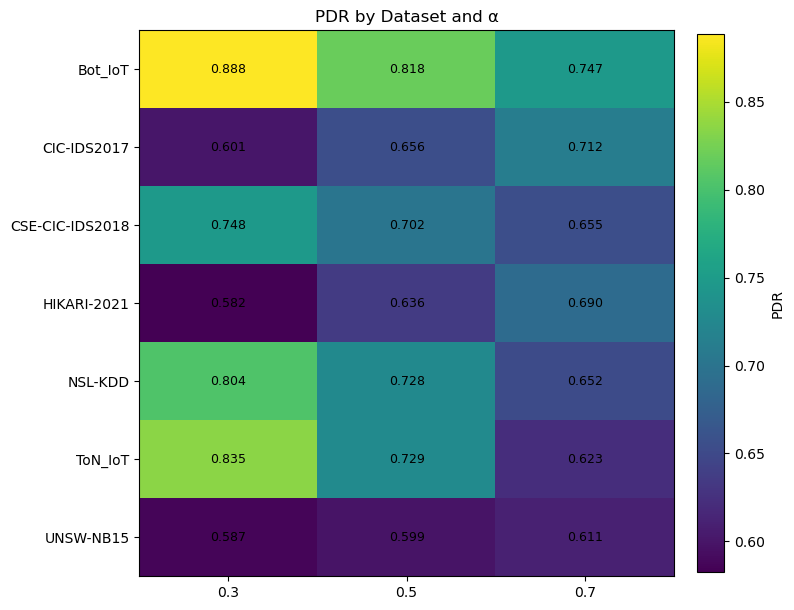

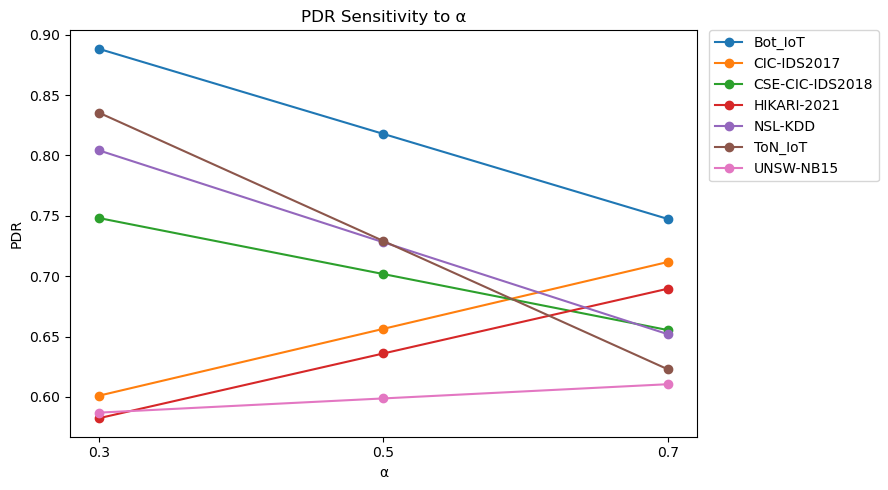

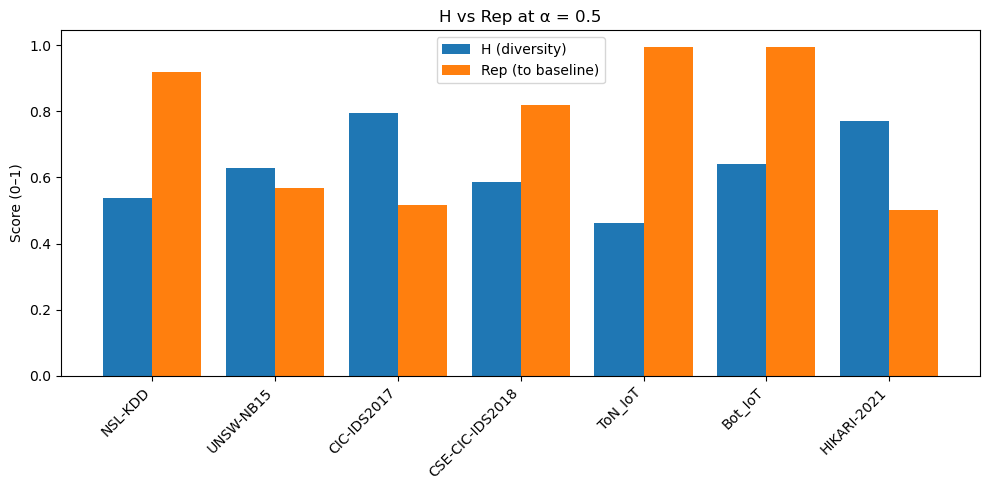

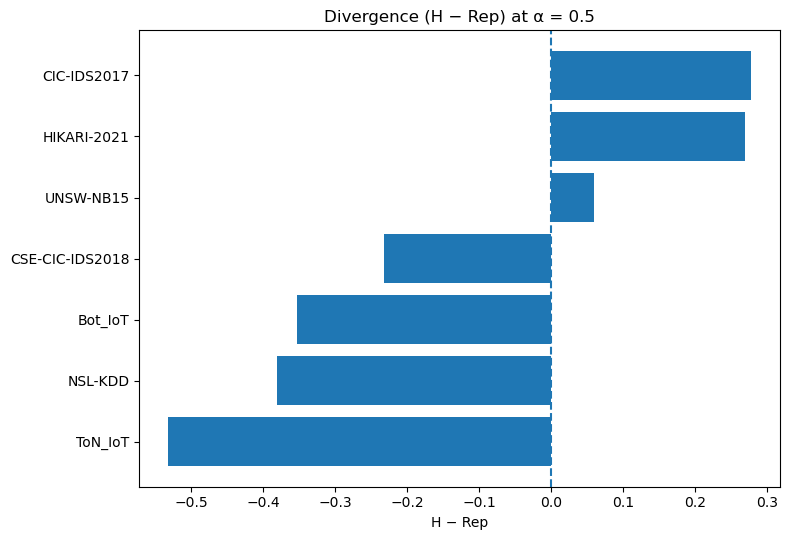

In [9]:
# ==========================
# PDR Visualizations
# ==========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("pdr_outputs", exist_ok=True)

# ---- 0) Sanity: reconstruct pivots we need ----
# df_long was created by the alpha-sweep cell
assert 'df_long' in globals(), "df_long not found. Run the alpha-sweep cell first."

# Ensure alpha columns are numeric and sorted
alphas = sorted(df_long['alpha'].unique().tolist())
pivot_pdr = df_long.pivot(index="dataset", columns="alpha", values="PDR")
pivot_pdr = pivot_pdr[alphas]  # column order
pivot_pdr = pivot_pdr.reset_index()

# Helper: get alpha=0.5 slice (or nearest if not present)
alpha_target = 0.5 if 0.5 in alphas else sorted(alphas, key=lambda a: abs(a-0.5))[0]
df05 = df_long[df_long["alpha"] == alpha_target].copy().reset_index(drop=True)

# ---------------------------
# 1) Heatmap: PDR by dataset × alpha
# ---------------------------
data = pivot_pdr[alphas].values
datasets_order = pivot_pdr["dataset"].tolist()

fig, ax = plt.subplots(figsize=(8, 0.6*len(datasets_order)+2))
im = ax.imshow(data, aspect='auto')

ax.set_xticks(range(len(alphas)))
ax.set_xticklabels([str(a) for a in alphas])
ax.set_yticks(range(len(datasets_order)))
ax.set_yticklabels(datasets_order)

for i in range(len(datasets_order)):
    for j in range(len(alphas)):
        ax.text(j, i, f"{data[i, j]:.3f}", ha='center', va='center', fontsize=9)

ax.set_title("PDR by Dataset and α")
cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("PDR", rotation=90)
plt.tight_layout()
plt.savefig("pdr_outputs/PDR_heatmap.png", dpi=200)
plt.show()

# ---------------------------
# 2) Line chart: PDR vs α (one line per dataset)
# ---------------------------
fig, ax = plt.subplots(figsize=(9, 5))
for name, grp in df_long.groupby("dataset"):
    g = grp.sort_values("alpha")
    ax.plot(g["alpha"], g["PDR"], marker='o', label=name)

ax.set_xlabel("α")
ax.set_ylabel("PDR")
ax.set_title("PDR Sensitivity to α")
ax.set_xticks(alphas)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.savefig("pdr_outputs/PDR_lines_by_dataset.png", dpi=200)
plt.show()

# ---------------------------
# 3) Grouped bars: H vs Rep at α=0.5
# ---------------------------
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df05))
w = 0.4

ax.bar(x - w/2, df05["H_diversity"], width=w, label="H (diversity)")
ax.bar(x + w/2, df05["Rep"],         width=w, label="Rep (to baseline)")

ax.set_xticks(x)
ax.set_xticklabels(df05["dataset"], rotation=45, ha='right')
ax.set_ylabel("Score (0–1)")
ax.set_title(f"H vs Rep at α = {alpha_target}")
ax.legend()
plt.tight_layout()
plt.savefig("pdr_outputs/H_vs_Rep_alpha05.png", dpi=200)
plt.show()

# ---------------------------
# 4) Diverging bars: (H − Rep) at α=0.5
#    > positive -> benefits when α increases (diversity > representativeness)
#    > negative -> loses when α increases (representativeness > diversity)
# ---------------------------
df05["H_minus_Rep"] = df05["H_diversity"] - df05["Rep"]
df05s = df05.sort_values("H_minus_Rep")

fig, ax = plt.subplots(figsize=(8, 0.5*len(df05s)+2))
ax.barh(df05s["dataset"], df05s["H_minus_Rep"])
ax.axvline(0, linestyle="--")
ax.set_xlabel("H − Rep")
ax.set_title(f"Divergence (H − Rep) at α = {alpha_target}")
plt.tight_layout()
plt.savefig("pdr_outputs/H_minus_Rep_alpha05.png", dpi=200)
plt.show()

# ---------------------------
# 5) Helper: Top-K protocols — dataset p_i vs projected baseline q_i'
#    Reads the per-dataset CSVs created earlier by the main PDR script.
# ---------------------------
def plot_topk_protocols(dataset_name: str, k: int = 10):
    csv_path = f"pdr_outputs/PDR_comparison_{dataset_name.replace(' ','_')}.csv"
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Not found: {csv_path}. Run the main PDR script to generate it.")
    df = pd.read_csv(csv_path)
    # guard for columns
    needed = {"protocol","p_i","q_i_proj"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"{csv_path} missing columns: {missing}")
    dft = df.sort_values("p_i", ascending=False).head(k).copy()

    x = np.arange(len(dft))
    w = 0.4
    fig, ax = plt.subplots(figsize=(max(8, 0.9*len(dft)), 5))
    ax.bar(x - w/2, dft["p_i"], width=w, label="Dataset pᵢ")
    ax.bar(x + w/2, dft["q_i_proj"], width=w, label="Baseline qᵢ′")

    ax.set_xticks(x)
    ax.set_xticklabels(dft["protocol"], rotation=45, ha='right')
    ax.set_ylabel("Proportion")
    ax.set_title(f"{dataset_name}: Top {k} Protocols — Dataset vs Baseline")
    ax.legend()
    plt.tight_layout()
    out = f"pdr_outputs/Top{str(k)}_protocols_{dataset_name.replace(' ','_')}.png"
    plt.savefig(out, dpi=200)
    plt.show()
    print(f"Saved: {out}")

# --- (Optional) quick calls for a couple datasets:
# plot_topk_protocols("HIKARI-2021", k=12)
# plot_topk_protocols("CIC-IDS2017", k=12)


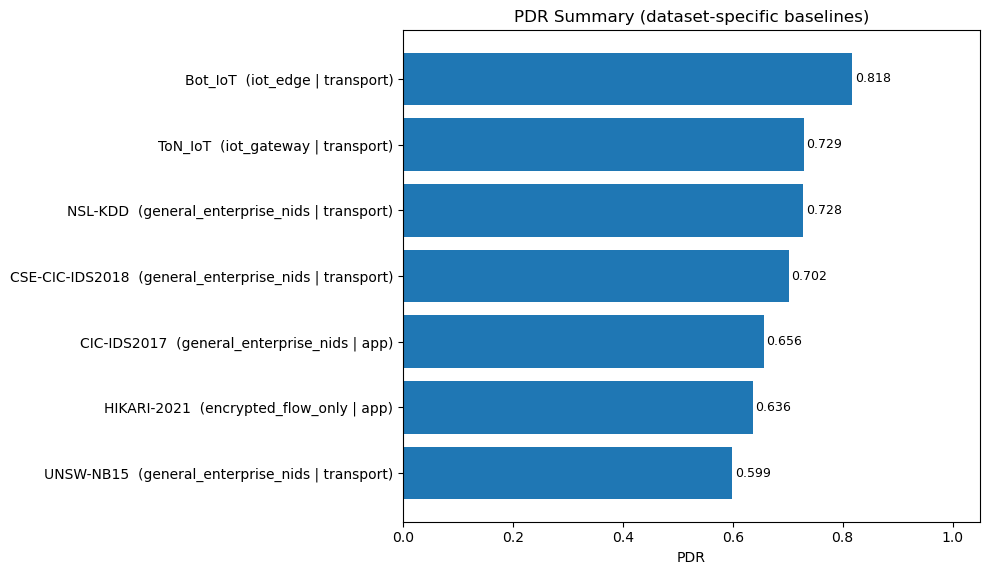

Saved: pdr_outputs/PDR_summary_bar.png


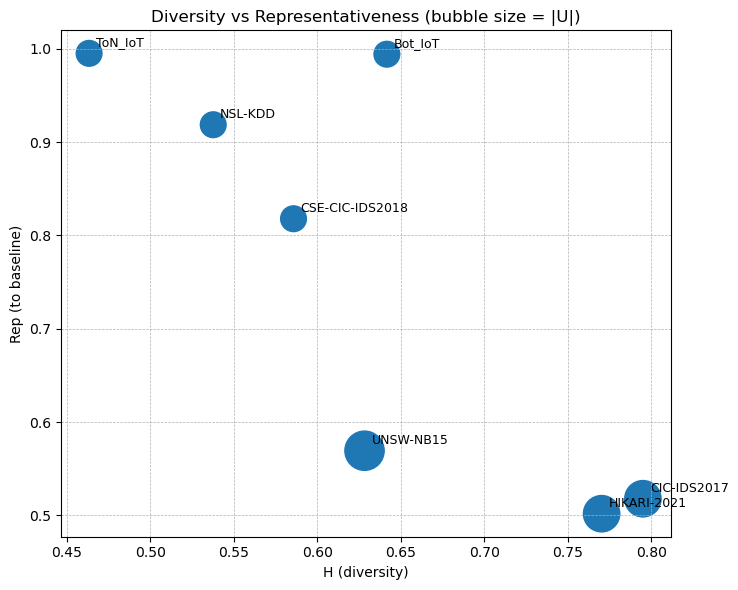

Saved: pdr_outputs/PDR_summary_scatter.png


In [11]:
# ==========================
# Visualize PDR summary CSV
# ==========================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

summary_csv = "pdr_outputs/PDR_summary_dataset_specific.csv"
assert os.path.exists(summary_csv), f"Missing {summary_csv}. Run the main PDR script first."

summary = pd.read_csv(summary_csv)

# 1) Horizontal bar chart of PDR (sorted), annotated with profile|layer
sum_sorted = summary.sort_values("PDR", ascending=True).reset_index(drop=True)
labels = sum_sorted["dataset"] + "  (" + sum_sorted["profile"] + " | " + sum_sorted["layer"] + ")"

fig, ax = plt.subplots(figsize=(10, 0.55*len(sum_sorted)+2))
ax.barh(labels, sum_sorted["PDR"])
for i, v in enumerate(sum_sorted["PDR"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=9)
ax.set_xlim(0, 1.05*max(1.0, sum_sorted["PDR"].max()))
ax.set_xlabel("PDR")
ax.set_title("PDR Summary (dataset-specific baselines)")
plt.tight_layout()
out1 = "pdr_outputs/PDR_summary_bar.png"
plt.savefig(out1, dpi=200)
plt.show()
print(f"Saved: {out1}")

# 2) Scatter: H vs Rep (alpha=0.5), bubble size = U_size; label each point
fig, ax = plt.subplots(figsize=(7.5, 6))
sizes = (sum_sorted["U_size"] / sum_sorted["U_size"].max()) * 800  # scale bubbles
ax.scatter(sum_sorted["H_diversity"], sum_sorted["Rep"], s=sizes)

for _, row in sum_sorted.iterrows():
    ax.annotate(row["dataset"], (row["H_diversity"], row["Rep"]), xytext=(5,5), textcoords="offset points", fontsize=9)

ax.set_xlabel("H (diversity)")
ax.set_ylabel("Rep (to baseline)")
ax.set_title("Diversity vs Representativeness (bubble size = |U|)")
ax.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
out2 = "pdr_outputs/PDR_summary_scatter.png"
plt.savefig(out2, dpi=200)
plt.show()
print(f"Saved: {out2}")
